# Heatmap of significantly differentially expressed genes

Shows the genes found significant in `differential_expression.ipynb` (padj < 0.05 and |log2FC| >= 0.5) across every sample, with a side bar marking **TB at diagnosis** vs **healthy controls**.

Run `differential_expression.ipynb` first.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PyComplexHeatmap import ClusterMapPlotter, HeatmapAnnotation, anno_simple

data_dir = Path("../data/SRP092402")
results_dir = Path(".")  # notebooks live in results/, next to their outputs

group_colors = {"TB (diagnosis)": "#d95f02", "Healthy control": "#1b9e77"}
direction_colors = {"Higher in TB": "#b2182b", "Lower in TB": "#2166ac"}

## Extract the significant genes

In [2]:
de_results = pd.read_csv(results_dir / "diff_expr_tb_vs_healthy.tsv", sep="\t", index_col="Ensembl")
sig_genes = de_results[de_results["direction"] != "Not significant"]
sig_genes.to_csv(results_dir / "significant_de_genes_tb_vs_healthy.tsv", sep="\t")

print(f"{len(sig_genes)} significant genes")
sig_genes["direction"].value_counts()

249 significant genes


direction
Higher in TB    172
Lower in TB      77
Name: count, dtype: int64

## Build the sample matrix

Same samples as the other notebooks: TB and healthy at diagnosis, with technical replicates averaged.

In [3]:
expression_df = pd.read_csv(data_dir / "SRP092402_Symbols.tsv", sep="\t", index_col="Ensembl")
metadata = pd.read_csv(data_dir / "metadata_SRP092402.tsv", sep="\t")

group_labels = {"tb subjects": "TB (diagnosis)", "healthy controls": "Healthy control"}
selected = metadata[
    metadata["refinebio_disease"].isin(group_labels)
    & (metadata["refinebio_time"] == "dx")
].copy()
selected["group"] = selected["refinebio_disease"].map(group_labels)
selected["sample_id"] = "S" + selected["refinebio_subject"].astype(str) + "_" + selected["refinebio_time"]
run_to_sample = selected.set_index("refinebio_accession_code")["sample_id"]

log_mat = np.log2(expression_df.loc[sig_genes.index, selected["refinebio_accession_code"]] + 1)
sample_mat = log_mat.T.groupby(run_to_sample).mean().T
sample_group = selected.drop_duplicates("sample_id").set_index("sample_id").loc[sample_mat.columns, "group"]

print(f"{sample_mat.shape[0]} genes x {sample_mat.shape[1]} samples")
sample_group.value_counts()

249 genes x 112 samples


group
TB (diagnosis)     91
Healthy control    21
Name: count, dtype: int64

## Scale each gene

Convert each gene to a z-score (subtract its mean across samples, divide by its standard deviation). Otherwise highly expressed genes would dominate the colors. Red means higher than that gene's average, blue means lower.

In [4]:
z_mat = sample_mat.sub(sample_mat.mean(axis=1), axis=0).div(sample_mat.std(axis=1), axis=0)

# Rows stay as Ensembl IDs: a few gene symbols map to more than one ID (e.g. DEFA1)
gene_direction = sig_genes.loc[z_mat.index, "direction"]

## Heatmap

Rows (genes) and columns (samples) are hierarchically clustered, without using the group labels. The top bar shows each sample's group; the left bar shows whether each gene is higher or lower in TB.

Starting..
Calculating row orders..
Reordering rows..
Calculating col orders..
Reordering cols..
Plotting matrix..


C:\Users\richa\AppData\Local\Programs\Python\Python313\Lib\site-packages\PyComplexHeatmap\clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
C:\Users\richa\AppData\Local\Programs\Python\Python313\Lib\site-packages\PyComplexHeatmap\clustermap.py:835: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


Plotting HeatmapAnnotations
Plotting HeatmapAnnotations
Plotting legends..
Estimated legend width: 37.395833333333336 mm


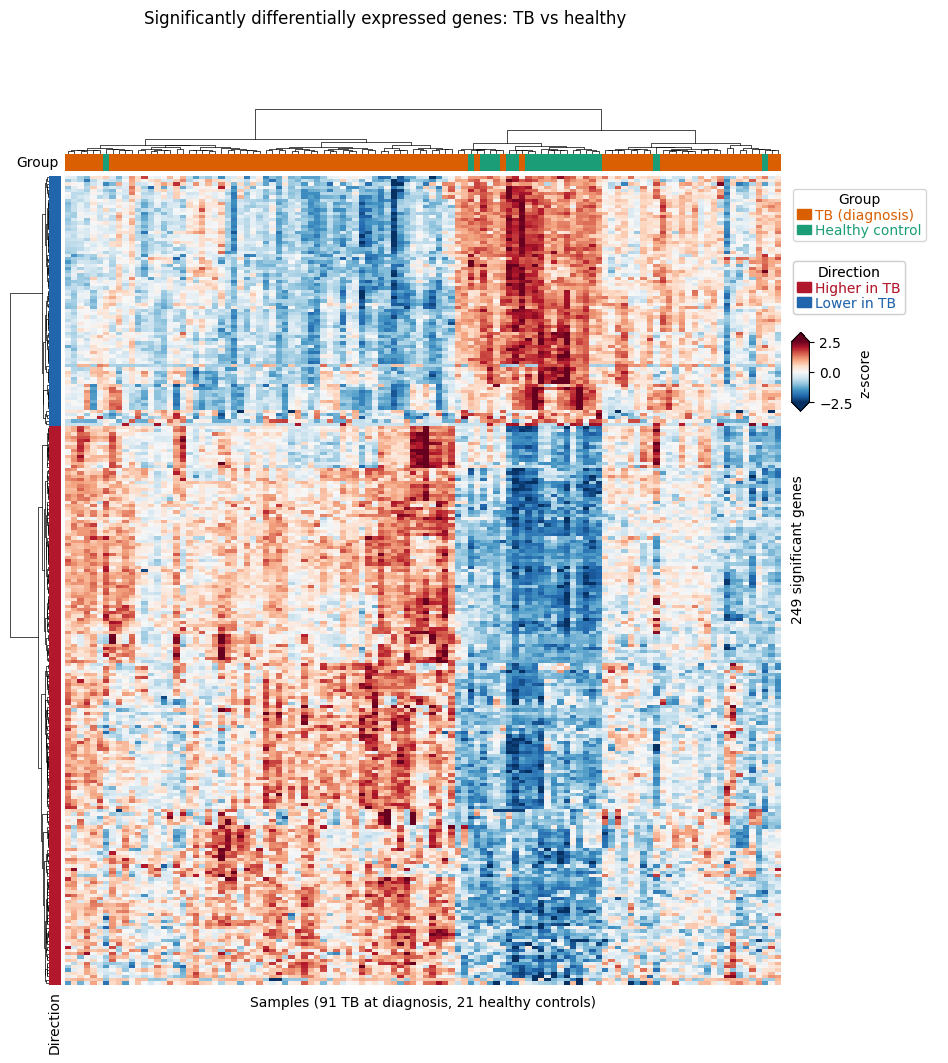

In [5]:
sample_bar = HeatmapAnnotation(
    Group=anno_simple(sample_group, colors=group_colors, legend=True, add_text=False, height=4),
    axis=1, label_side="left",
)
gene_bar = HeatmapAnnotation(
    Direction=anno_simple(gene_direction, colors=direction_colors, legend=True, add_text=False),
    axis=0, label_side="bottom",
)

fig = plt.figure(figsize=(10, 10))
ClusterMapPlotter(
    data=z_mat,
    top_annotation=sample_bar,
    left_annotation=gene_bar,
    row_cluster=True, col_cluster=True,
    row_dendrogram=True, col_dendrogram=True,
    show_rownames=False, show_colnames=False,
    cmap="RdBu_r", vmin=-2.5, vmax=2.5,
    label="z-score", legend=True,
    xlabel="Samples (91 TB at diagnosis, 21 healthy controls)",
    ylabel=f"{len(z_mat)} significant genes",
    xlabel_side="bottom", ylabel_side="right",
)
fig.suptitle("Significantly differentially expressed genes: TB vs healthy", y=0.98)
fig.savefig(results_dir / "heatmap_sig_genes_tb_vs_healthy.png", dpi=150, bbox_inches="tight")
plt.show()

## How well does the clustering match the groups?

In [6]:
from scipy.cluster.hierarchy import fcluster, linkage

# Same clustering as the heatmap's sample tree (PyComplexHeatmap default: Ward, Euclidean)
sample_clusters = fcluster(linkage(z_mat.T.values, method="ward", metric="euclidean"), t=2, criterion="maxclust")
pd.crosstab(pd.Series(sample_clusters, index=z_mat.columns, name="cluster"), sample_group)

group,Healthy control,TB (diagnosis)
cluster,,
1,1,60
2,20,31


## Summary

**Data:** 249 significant genes (172 higher in TB, 77 lower in TB) across 112 samples (91 TB at diagnosis, 21 healthy controls), each gene scaled to a z-score. Genes and samples were clustered without using the group labels.

**Genes** split cleanly into two blocks that match the direction bar: the lymphocyte genes that are lower in TB (top, blue bar) and the interferon, complement, and neutrophil genes that are higher in TB (bottom, red bar). Within each block, genes rise and fall together across samples, as expected for genes from the same cell types and pathways.

**Samples**
- The healthy controls cluster together in the middle: high lymphocyte genes (red, top) and low TB-response genes (blue, bottom), the mirror image of most TB samples.
- The sample tree's first split separates 60 TB + 1 healthy (left) from 20 healthy + 31 TB (right). So 20 of 21 healthy controls end up together, but the right branch also holds a third of the TB patients.
- The TB patients aren't uniform. The block on the left shows the strongest TB pattern, while the TB patients in the right branch have a weaker pattern, closer to healthy. These could be patients with milder or earlier disease, the same "TB near the controls" samples seen in the PCA and UMAP plots.

**Caveat:** these genes were chosen *because* they differ between the groups, so some separation is guaranteed. The heatmap shows how consistent the pattern is across individual people, not independent proof that the groups differ; for that, see the unsupervised PCA/t-SNE/UMAP plots, which used no labels.